# NeuroGolf Strategy 2 Debug Notebook
Conv2d Logic Gate System — visual debugging and analysis.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

sys.path.insert(0, os.path.abspath('.'))
from main import (
    load_task, analyze_task, build_model, verify_model,
    detect_color_mapping, detect_neighbor_rules,
    grid_to_onehot, CHANNELS, GRID_H, GRID_W
)

COLORS = [
    '#000000', '#1E93FF', '#F2314E', '#4ECC30', '#FFDD00',
    '#999999', '#E53BA3', '#FF851C', '#88D8F1', '#931131',
    '#F0F0F0', '#927556'
]
CMAP = ListedColormap(COLORS)

def plot_grid(ax, grid, title='', fontsize=12):
    if not grid or not grid[0]:
        ax.set_title(title + ' (empty)', fontsize=fontsize)
        return
    H, W = len(grid), len(grid[0])
    arr = np.array(grid)
    ax.imshow(arr, cmap=CMAP, vmin=0, vmax=11, interpolation='nearest')
    ax.set_title(title, fontsize=fontsize, fontweight='bold')
    ax.set_xticks(range(W))
    ax.set_yticks(range(H))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    for r in range(H):
        for c in range(W):
            val = grid[r][c]
            color = 'white' if val in [0, 9] else 'black'
            ax.text(c, r, str(val), ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')

def plot_diff(ax, expected, actual, title=''):
    H, W = len(expected), len(expected[0])
    diff = np.zeros((H, W, 3))
    for r in range(H):
        for c in range(W):
            diff[r][c] = [0.85, 1.0, 0.85] if expected[r][c] == actual[r][c] else [1.0, 0.75, 0.75]
    ax.imshow(diff, interpolation='nearest')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(W))
    ax.set_yticks(range(H))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    for r in range(H):
        for c in range(W):
            e, a = expected[r][c], actual[r][c]
            if e != a:
                ax.text(c, r, f'{e}→{a}', ha='center', va='center',
                        fontsize=6, color='red', fontweight='bold')

print('Ready.')

Ready.


## 1. Rule Detection Deep Dive
Pick any task and see exactly what rules the detector finds.

In [2]:
TASK_NUM = 4  # <-- change this

task = load_task(TASK_NUM)
print(f'Task {TASK_NUM:03d} | train: {len(task["train"])} demos | test: {len(task["test"])}')

# Show color mapping detection
all_exs = task['train'] + task.get('test', [])
color_map = detect_color_mapping(all_exs)
print(f'\nColor mapping: {color_map}')

# Show neighborhood rules
neighbor_rules = detect_neighbor_rules(task['train'])
print(f'\nNeighborhood rules ({len(neighbor_rules) if neighbor_rules else 0}):')
if neighbor_rules:
    for i, rule in enumerate(neighbor_rules):
        print(f'  Rule {i}: src={rule["src_color"]} dst={rule["dst_color"]} '
              f'neighbor_color={rule["neighbor_color"]} min_count={rule["min_count"]}')

# Show what the overall strategy is
strategy = analyze_task(task)
print(f'\nSelected strategy: {strategy[0] if strategy else None}')

Task 004 | train: 2 demos | test: 1

Color mapping: None

Neighborhood rules (3):
  Rule 0: src=0 dst=6 neighbor_color=6 min_count=2
  Rule 1: src=0 dst=2 neighbor_color=2 min_count=2
  Rule 2: src=0 dst=8 neighbor_color=8 min_count=2

Selected strategy: neighborhood


## 2. Visualize All Demos

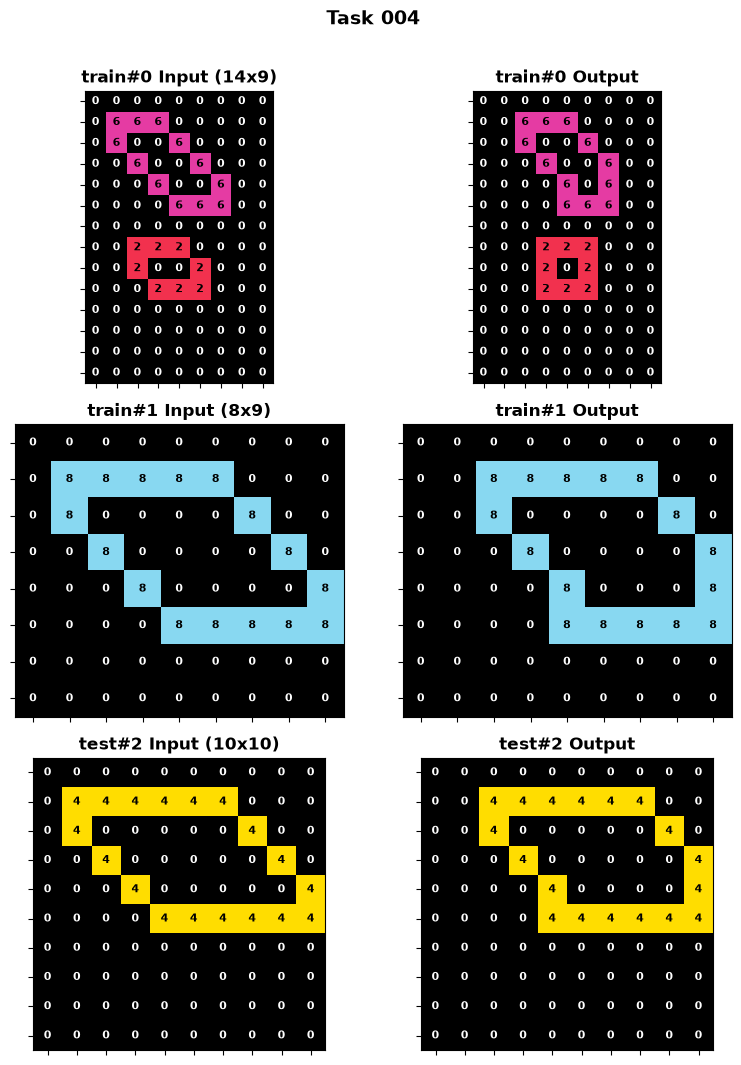

In [3]:
all_exs = task['train'] + task.get('test', [])
nrows = len(all_exs)
fig, axes = plt.subplots(nrows, 2, figsize=(8, 3.5 * nrows))
if nrows == 1:
    axes = [axes]
for i, ex in enumerate(all_exs):
    split = 'train' if i < len(task['train']) else 'test'
    h, w = len(ex['input']), len(ex['input'][0])
    plot_grid(axes[i][0], ex['input'], f'{split}#{i} Input ({h}x{w})')
    plot_grid(axes[i][1], ex['output'], f'{split}#{i} Output')
fig.suptitle(f'Task {TASK_NUM:03d}', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

## 3. Inspect Neighborhood Changes
For each changed pixel, show what neighbors it had.

In [4]:
ex = task['train'][0]
grid_in, grid_out = ex['input'], ex['output']
h, w = len(grid_in), len(grid_in[0])

print(f'Changed pixels in demo 0 ({h}x{w}):')
print(f'{"Pos":>8s} {"In":>3s} {"Out":>3s}  Neighbors (color:count)')
print('-' * 60)
for r in range(h):
    for c in range(w):
        ic, oc = grid_in[r][c], grid_out[r][c]
        if ic == oc:
            continue
        neighbors = {}
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < h and 0 <= nc < w:
                nv = grid_in[nr][nc]
                neighbors[nv] = neighbors.get(nv, 0) + 1
        nb_str = ' '.join(f'{k}:{v}' for k, v in sorted(neighbors.items()))
        print(f'  ({r:2d},{c:2d})  {ic:3d} {oc:3d}  {nb_str}')

Changed pixels in demo 0 (14x9):
     Pos  In Out  Neighbors (color:count)
------------------------------------------------------------
  ( 1, 1)    6   0  0:2 6:2
  ( 1, 4)    0   6  0:2 6:2
  ( 2, 1)    6   0  0:3 6:1
  ( 2, 2)    0   6  0:1 6:3
  ( 2, 4)    6   0  0:4
  ( 2, 5)    0   6  0:2 6:2
  ( 3, 2)    6   0  0:4
  ( 3, 3)    0   6  0:2 6:2
  ( 3, 5)    6   0  0:4
  ( 3, 6)    0   6  0:2 6:2
  ( 4, 3)    6   0  0:4
  ( 4, 4)    0   6  0:2 6:2
  ( 7, 2)    2   0  0:2 2:2
  ( 7, 5)    0   2  0:2 2:2
  ( 8, 2)    2   0  0:3 2:1
  ( 8, 3)    0   2  0:1 2:3


## 4. Debug the ONNX Model
Run the actual ONNX model step by step and visualize intermediate tensors.

In [5]:
model_path = f'output/task{TASK_NUM:03d}.onnx'
if not os.path.exists(model_path):
    print(f'{model_path} not found — run main.py first or pick a solved task (16, 276, 309, 337).')
else:
    import onnxruntime
    sess = onnxruntime.InferenceSession(model_path)
    
    ex = task['train'][0]
    inp = grid_to_onehot(ex['input'])
    expected = grid_to_onehot(ex['output'])
    
    # Get all intermediate outputs
    output_names = [o.name for o in sess.get_outputs()]
    all_outputs = sess.run(None, {'input': inp})
    
    final_out = all_outputs[0]
    final_bin = (final_out > 0.0).astype(np.float32)
    
    h, w = len(ex['input']), len(ex['input'][0])
    
    # Build predicted grid
    pred_grid = []
    for r in range(h):
        row = [int(np.argmax(final_out[0, :, r, c])) for c in range(w)]
        pred_grid.append(row)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    plot_grid(axes[0], ex['input'], 'Input')
    plot_grid(axes[1], ex['output'], 'Expected')
    plot_grid(axes[2], pred_grid, 'ONNX Output')
    plot_diff(axes[3], ex['output'], pred_grid, 'Diff')
    fig.tight_layout()
    plt.show()
    
    match = np.array_equal(final_bin, expected)
    print(f'Match: {match}')
    
    # Show channel values for changed pixels
    print(f'\nONNX output channel values at changed pixels:')
    for r in range(h):
        for c in range(w):
            ic, oc = ex['input'][r][c], ex['output'][r][c]
            if ic != oc:
                channels = [f'{final_out[0,ch,r,c]:.2f}' for ch in range(CHANNELS)]
                print(f'  ({r},{c}): in={ic} out={oc} pred={pred_grid[r][c]} channels=[{" ".join(channels)}]')

output/task004.onnx not found — run main.py first or pick a solved task (16, 276, 309, 337).


## 5. Color Map Model Deep Dive
For tasks solved by color mapping, visualize the 1x1 Conv2d kernel.

Task 016 strategy: color_map
Color mapping: {3: 4, 1: 5, 2: 6, 8: 9, 5: 1, 6: 2, 9: 8, 4: 3}


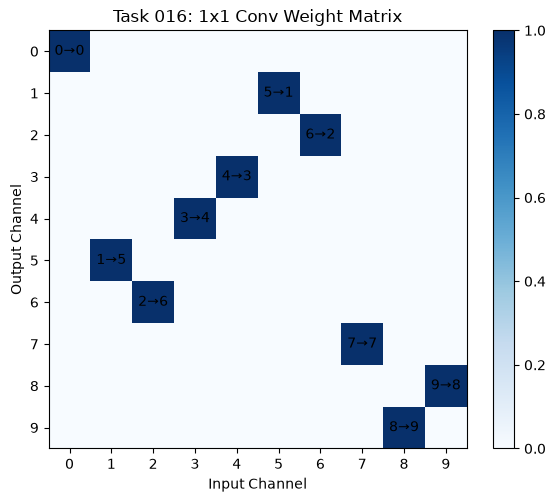

  Demo 0: OK
  Demo 1: OK
  Demo 2: OK
  Demo 3: OK
  Demo 4: OK


In [6]:
TASK_NUM_CM = 16  # <-- a color_map task

task_cm = load_task(TASK_NUM_CM)
strategy = analyze_task(task_cm)
print(f'Task {TASK_NUM_CM:03d} strategy: {strategy[0] if strategy else None}')

if strategy and strategy[0] == 'color_map':
    cm = strategy[1]
    print(f'Color mapping: {cm}')
    
    # Show the mapping matrix
    W = np.zeros((CHANNELS, CHANNELS), dtype=np.float32)
    for ic in range(CHANNELS):
        oc = cm.get(ic, ic)
        W[oc, ic] = 1.0
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(W, cmap='Blues', vmin=0, vmax=1)
    ax.set_xlabel('Input Channel')
    ax.set_ylabel('Output Channel')
    ax.set_title(f'Task {TASK_NUM_CM:03d}: 1x1 Conv Weight Matrix')
    ax.set_xticks(range(CHANNELS))
    ax.set_yticks(range(CHANNELS))
    for i in range(CHANNELS):
        for j in range(CHANNELS):
            if W[i, j] > 0:
                ax.text(j, i, f'{j}→{i}', ha='center', va='center', fontsize=10)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
    
    # Verify
    model_path = f'output/task{TASK_NUM_CM:03d}.onnx'
    if os.path.exists(model_path):
        import onnxruntime
        sess = onnxruntime.InferenceSession(model_path)
        all_exs = task_cm['train'] + task_cm.get('test', [])
        for i, ex in enumerate(all_exs):
            inp = grid_to_onehot(ex['input'])
            out = sess.run(['output'], {'input': inp})[0]
            out_bin = (out > 0.0).astype(np.float32)
            exp = grid_to_onehot(ex['output'])
            match = np.array_equal(out_bin, exp)
            print(f'  Demo {i}: {"OK" if match else "FAIL"}')

## 6. Task Scanner: Distribution of Rule Types

In [7]:
from collections import Counter

stats = Counter()
task_files = sorted(f for f in os.listdir('..') 
                    if f.startswith('task') and f.endswith('.json') and len(f) == 13)
# Oops, wrong dir. Let's fix.
tasks_dir = os.path.join('..', 'neurogolf-2026')
task_files = sorted(f for f in os.listdir(tasks_dir)
                    if f.startswith('task') and f.endswith('.json'))

for tf in task_files:
    num = int(tf.replace('task', '').replace('.json', ''))
    t = load_task(num)
    strat = analyze_task(t)
    if strat is None:
        stats['no_rule'] += 1
    else:
        stats[strat[0]] += 1

print('Rule Type Distribution (400 tasks):')
for k, v in stats.most_common():
    print(f'  {k:25s} {v:4d}')

Rule Type Distribution (400 tasks):
  no_rule                    292
  neighborhood               104
  color_map                    4


## 7. Kernel Visualization for Neighborhood Rules
See exactly what the Conv2d kernel looks like for a neighborhood task.

Task 004 rules:
  Rule 0: src=0 -> dst=6 (need >= 2 neighbors of color 6)
  Rule 1: src=0 -> dst=2 (need >= 2 neighbors of color 2)
  Rule 2: src=0 -> dst=8 (need >= 2 neighbors of color 8)


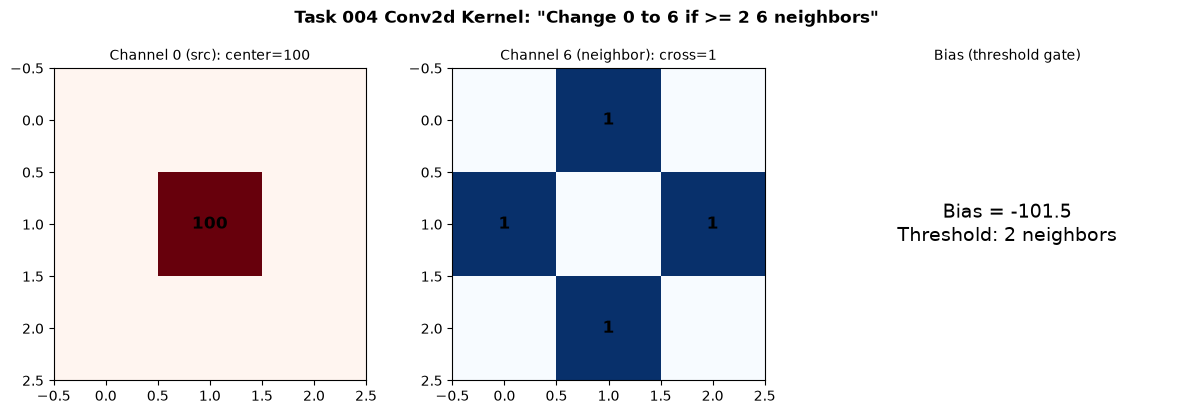

In [8]:
TASK_NUM_NB = 4  # <-- a neighborhood task

task_nb = load_task(TASK_NUM_NB)
rules = detect_neighbor_rules(task_nb['train'])
print(f'Task {TASK_NUM_NB:03d} rules:')
for i, rule in enumerate(rules):
    print(f'  Rule {i}: src={rule["src_color"]} -> dst={rule["dst_color"]} '
          f'(need >= {rule["min_count"]} neighbors of color {rule["neighbor_color"]})')

# Show the Conv2d kernel for rule 0
if rules:
    rule = rules[0]
    src, ncol = rule['src_color'], rule['neighbor_color']
    
    # Build kernel visualization
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Show which channels have non-zero weights
    W = np.zeros((3, 3))
    W[1, 1] = 100  # center (src channel)
    axes[0].imshow(W, cmap='Reds', vmin=0, vmax=100)
    axes[0].set_title(f'Channel {src} (src): center=100', fontsize=10)
    for i in range(3):
        for j in range(3):
            v = int(W[i, j])
            if v > 0:
                axes[0].text(j, i, str(v), ha='center', va='center', fontsize=12, fontweight='bold')
    
    W2 = np.zeros((3, 3))
    W2[0, 1] = 1  # top
    W2[1, 0] = 1  # left
    W2[1, 2] = 1  # right
    W2[2, 1] = 1  # bottom
    axes[1].imshow(W2, cmap='Blues', vmin=0, vmax=1)
    axes[1].set_title(f'Channel {ncol} (neighbor): cross=1', fontsize=10)
    for i in range(3):
        for j in range(3):
            v = int(W2[i, j])
            if v > 0:
                axes[1].text(j, i, str(v), ha='center', va='center', fontsize=12, fontweight='bold')
    
    bias = -(100 + rule['min_count'] - 0.5)
    axes[2].text(0.5, 0.5, f'Bias = {bias:.1f}\nThreshold: {rule["min_count"]} neighbors',
                 ha='center', va='center', fontsize=14, transform=axes[2].transAxes)
    axes[2].set_axis_off()
    axes[2].set_title('Bias (threshold gate)', fontsize=10)
    
    fig.suptitle(f'Task {TASK_NUM_NB:03d} Conv2d Kernel: "Change {src} to {rule["dst_color"]} if >= {rule["min_count"]} {ncol} neighbors"',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()

## 8. Why Neighborhood Models Fail
Explore why a specific neighborhood task fails verification.

In [9]:
# Pick a task that detects neighborhood rules but fails
FAIL_TASK = 87

t = load_task(FAIL_TASK)
rules = detect_neighbor_rules(t['train'])
print(f'Task {FAIL_TASK:03d}: {len(rules)} rules detected')
for i, rule in enumerate(rules):
    print(f'  Rule {i}: {rule["src_color"]} -> {rule["dst_color"]} (need {rule["min_count"]} x color {rule["neighbor_color"]})')

# Check: is the rule consistent across ALL changed pixels?
ex = t['train'][0]
grid_in, grid_out = ex['input'], ex['output']
h, w = len(grid_in), len(grid_in[0])

print(f'\nChanged pixels analysis:')
for r in range(h):
    for c in range(w):
        ic, oc = grid_in[r][c], grid_out[r][c]
        if ic == oc:
            continue
        # Count ALL neighbors (including same color)
        all_nb = {}
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < h and 0 <= nc < w:
                nv = grid_in[nr][nc]
                all_nb[nv] = all_nb.get(nv, 0) + 1
        print(f'  ({r},{c}): {ic}->{oc} | neighbors: {dict(sorted(all_nb.items()))}')

print(f'\nMultiple rules = model only uses first rule = FAIL')

Task 087: 13 rules detected
  Rule 0: 2 -> 8 (need 2 x color 1)
  Rule 1: 1 -> 2 (need 2 x color 2)
  Rule 2: 8 -> 2 (need 2 x color 1)
  Rule 3: 8 -> 2 (need 1 x color 2)
  Rule 4: 4 -> 2 (need 1 x color 2)
  Rule 5: 2 -> 4 (need 1 x color 4)
  Rule 6: 2 -> 4 (need 1 x color 9)
  Rule 7: 8 -> 5 (need 1 x color 5)
  Rule 8: 5 -> 8 (need 1 x color 8)
  Rule 9: 2 -> 3 (need 1 x color 3)
  Rule 10: 2 -> 3 (need 2 x color 9)
  Rule 11: 3 -> 2 (need 1 x color 2)
  Rule 12: 3 -> 2 (need 1 x color 9)

Changed pixels analysis:
  (0,0): 2->1 | neighbors: {2: 2}
  (0,1): 2->8 | neighbors: {1: 2, 2: 1}
  (0,2): 1->2 | neighbors: {2: 2}
  (2,0): 2->1 | neighbors: {2: 1, 8: 1}
  (2,1): 8->2 | neighbors: {1: 2, 2: 1}
  (2,2): 1->2 | neighbors: {2: 1, 8: 1}

Multiple rules = model only uses first rule = FAIL
